In [ ]:
import SoccerNet
from SoccerNet.Downloader import SoccerNetDownloader
mySoccerNetDownloader=SoccerNetDownloader(LocalDirectory="/Users/laithtahboub/CMSC426/SoccerAnalyticsComputerVision/data")

In [ ]:
#download from scratch.
mySoccerNetDownloader.password = "s0cc3rn3t"
mySoccerNetDownloader.downloadDataTask(
        task="gamestate-2024",
        split=["valid"],
    )

In [ ]:
!unzip data/gamestate-2024/valid.zip

In [13]:
import json
import pathlib as p

GSR = p.Path("/Users/laithtahboub/CMSC426/SoccerAnalyticsComputerVision/data")
clips = sorted(p for p in GSR.iterdir() if p.is_dir())
clip_dir = clips[0]
print(clip_dir)
labels = json.loads((clip_dir / "Labels-GameState.json").read_text())

print(clip_dir.name, list(labels.keys()))
labels["info"]

/Users/laithtahboub/CMSC426/SoccerAnalyticsComputerVision/data/SNGS-021
SNGS-021 ['info', 'images', 'annotations', 'categories']


{'version': '1.3',
 'game_id': '2',
 'id': '021',
 'num_tracklets': '25',
 'action_position': '82617',
 'action_class': 'Kick-off',
 'visibility': 'visible',
 'game_time_start': '1 - 01:16',
 'game_time_stop': '1 - 01:46',
 'clip_start': '76000',
 'clip_stop': '106000',
 'name': 'SNGS-021',
 'im_dir': 'img1',
 'frame_rate': 25,
 'seq_length': 750,
 'im_ext': '.jpg'}

In [7]:
# what an image entry looks like (has the homography / calibration)
labels["images"][0]

{'is_labeled': True,
 'image_id': '2021000001',
 'file_name': '000001.jpg',
 'height': 1080,
 'width': 1920,
 'has_labeled_person': True,
 'has_labeled_pitch': True,
 'has_labeled_camera': True,
 'ignore_regions_y': [],
 'ignore_regions_x': []}

In [8]:
# what an annotation looks like (bbox, team, role, jersey, track_id)
labels["annotations"][0]

{'id': '2021000001',
 'image_id': '2021000001',
 'track_id': 1,
 'supercategory': 'object',
 'category_id': 1,
 'attributes': {'role': 'player', 'jersey': '3', 'team': 'right'},
 'bbox_image': {'x': 1699,
  'y': 236,
  'x_center': 1715.5,
  'y_center': 276.0,
  'w': 33,
  'h': 80},
 'bbox_pitch': {'x_bottom_left': 14.762675703825428,
  'y_bottom_left': -20.83053095635082,
  'x_bottom_right': 15.432421464604555,
  'y_bottom_right': -20.76330413692191,
  'x_bottom_middle': 15.098003934563284,
  'y_bottom_middle': -20.797045698889935},
 'bbox_pitch_raw': {'x_bottom_left': 14.856741657087928,
  'y_bottom_left': -20.818658674119078,
  'x_bottom_right': 15.540939920786764,
  'y_bottom_right': -20.751109537245394,
  'x_bottom_middle': 15.199318544820853,
  'y_bottom_middle': -20.7850231451995}}

In [9]:
labels["categories"]

[{'supercategory': 'object', 'id': 1, 'name': 'player'},
 {'supercategory': 'object', 'id': 2, 'name': 'goalkeeper'},
 {'supercategory': 'object', 'id': 3, 'name': 'referee'},
 {'supercategory': 'object', 'id': 4, 'name': 'ball'},
 {'supercategory': 'pitch',
  'id': 5,
  'name': 'pitch',
  'lines': ['Big rect. left bottom',
   'Big rect. left main',
   'Big rect. left top',
   'Big rect. right bottom',
   'Big rect. right main',
   'Big rect. right top',
   'Circle central',
   'Circle left',
   'Circle right',
   'Goal left crossbar',
   'Goal left post left',
   'Goal left post right',
   'Goal right crossbar',
   'Goal right post left',
   'Goal right post right',
   'Middle line',
   'Side line bottom',
   'Side line left',
   'Side line right',
   'Side line top',
   'Small rect. left bottom',
   'Small rect. left main',
   'Small rect. left top',
   'Small rect. right bottom',
   'Small rect. right main',
   'Small rect. right top']},
 {'supercategory': 'camera', 'id': 6, 'name':

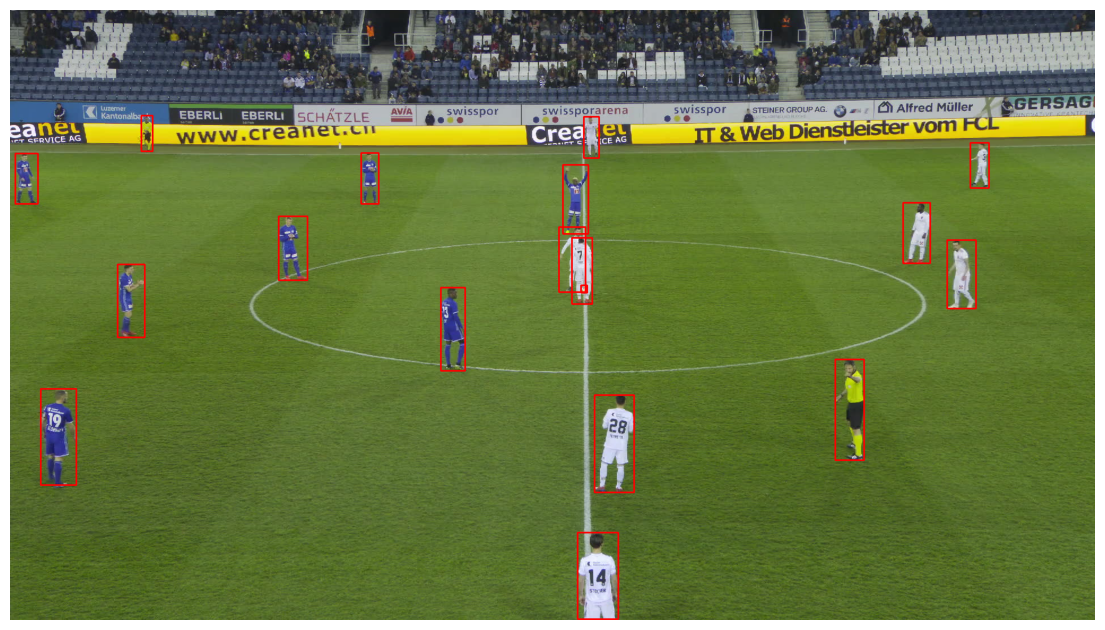

In [ ]:
# how do the data's bounding boxes look like?
import cv2, matplotlib.pyplot as plt

img_entry = labels["images"][0]
img = cv2.cvtColor(cv2.imread(str(clip_dir / "img1" / img_entry["file_name"])), cv2.COLOR_BGR2RGB)

for ann in labels["annotations"]:
    if ann["image_id"] != img_entry["image_id"] or "bbox_image" not in ann: # not all image have bbox
        continue
    b = ann["bbox_image"]
    x, y, w, h = int(b["x"]), int(b["y"]), int(b["w"]), int(b["h"])
    cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)

plt.figure(figsize=(14, 8)); plt.imshow(img); plt.axis("off");

In [ ]:
"""
Our goal:
Receive a soccer clip, any camera angle, and compute homography to project to 2D. Use
Soccernet's pre-built detection pipeline to localize players and ball (probably).
"""